# HR Analytics: Predicting Employee Attrition

In this project, we explore an HR dataset to understand the factors contributing to employee attrition and build predictive models to identify employees who are likely to leave the organization. By leveraging data-driven insights, the goal is to support HR decision-making and develop proactive strategies for employee retention.

---

## 1. Import Required Libraries
Import necessary libraries for data manipulation, visualization, modeling, and explainability (e.g., pandas, matplotlib, seaborn, scikit-learn, xgboost, shap).

## 2. Load the Dataset
Read the dataset and display initial rows to understand the structure.

## 3. Exploratory Data Analysis (EDA)
- Check dataset shape, types, missing values
- Statistical summaries
- Visualize distributions and relationships
- Explore attrition patterns across features

## 4. Data Preprocessing
- Handle missing values
- Encode categorical variables (Label or One-Hot Encoding)
- Feature scaling (especially for Logistic Regression)
- Split data into features (X) and target (y)
- Train-test split

## 5. Model Building
- Train multiple classification models:
  - Logistic Regression

## 6. Model Evaluation
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Score
- Confusion Matrix
- ROC Curves for model comparison

## 7. Model Explainability with SHAP
- Initialize SHAP explainer for each model:
  - `shap.LinearExplainer` for Logistic Regression
  - `shap.TreeExplainer` for tree-based models (e.g., XGBoost, Random Forest)
- Generate SHAP values for the test set
- Visualize explanations:
  - Summary plot
  - Force plot (for individual predictions)
  - Dependence plot (for feature interactions)
- Interpret which features drive attrition risk and how

## 8. Hyperparameter Tuning (Optional)
- Use GridSearchCV / RandomizedSearchCV for tuning best-performing models

## 9. Final Model and Prediction
- Choose best model based on evaluation + interpretability
- Predict on test set or new data

## 10. Conclusion & Business Insights
- Highlight key factors leading to attrition
- Recommend HR strategies based on model insights



#
# Libraries


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# About the Dataset

In [2]:
data= pd.read_csv(r"C:\Users\Rohan\Downloads\IBM-HR-Employee-Attrition.csv")
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

##
## From the about inferences we can see that the data is clean 
## So we can now decide to remove unnecessary columns
##

In [7]:
#Getting all the numeric columns
data.select_dtypes(np.number)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [8]:
# Converting the numeric data to categorical for visualization

data['Education']=data['Education'].map({1:'No Education',2:'School',3:'Collage',4:'Graduation',5:'Masters'})

data['EnvironmentSatisfaction']=data['EnvironmentSatisfaction'].map({1:'Low',2:'Medium',3:'High',4:'Very High'})

data["JobInvolvement"] = data["JobInvolvement"].map({1:"Low",2:"Medium",3:"High",4:"Very High"})

data["JobLevel"] = data["JobLevel"].map({1:"Entry Level",2:"Junior Level",3:"Mid Level",4:"Senior Level", 5:"Executive Level"})

data["JobSatisfaction"] = data["JobSatisfaction"].map({1:"Low",2:"Medium",3:"High",4:"Very High"})

data["PerformanceRating"] = data["PerformanceRating"].map({1:"Low",2:"Good",3:"Excellent",4:"Outstanding"})

data["RelationshipSatisfaction"] = data["RelationshipSatisfaction"].map({1:"Low",2:"Medium",3:"High",4:"Very High"})

data["WorkLifeBalance"] = data["WorkLifeBalance"].map({1:"Bad",2:"Good",3:"Better",4:"Best"})


In [9]:
# Getting all the Categorical columns
categorical=data.select_dtypes(include='O')
categorical

,Attrition,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,Over18,OverTime,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance
0,Yes,Travel_Rarely,Sales,School,Life Sciences,Medium,Female,High,Junior Level,Sales Executive,Very High,Single,Y,Yes,Excellent,Low,Bad
1,No,Travel_Frequently,Research & Development,No Education,Life Sciences,High,Male,Medium,Junior Level,Research Scientist,Medium,Married,Y,No,Outstanding,Very High,Better
2,Yes,Travel_Rarely,Research & Development,School,Other,Very High,Male,Medium,Entry Level,Laboratory Technician,High,Single,Y,Yes,Excellent,Medium,Better
3,No,Travel_Frequently,Research & Development,Graduation,Life Sciences,Very High,Female,High,Entry Level,Research Scientist,High,Married,Y,Yes,Excellent,High,Better
4,No,Travel_Rarely,Research & Development,No Education,Medical,Low,Male,High,Entry Level,Laboratory Technician,Medium,Married,Y,No,Excellent,Very High,Better
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,School,Medical,High,Male,Very High,Junior Level,Laboratory Technician,Very High,Married,Y,No,Excellent,High,Better
1466,No,Travel_Rarely,Research & Development,No Education,Medical,Very High,Male,Medium,Mid Level,Healthcare Representative,Low,Married,Y,No,Excellent,Low,Better
1467,No,Travel_Rarely,Research & Development,Collage,Life Sciences,Medium,Male,Very High,Junior Level,Manufacturing Director,Medium,Married,Y,Yes,Outstanding,Medium,Better
1468,No,Travel_Frequently,Sales,Collage,Medical,Very High,Male,Medium,Junior Level,Sales Executive,Medium,Married,Y,No,Excellent,Very High,Good


In [10]:
# Viewing all the values in columns
for column in categorical.columns:
    print(f'the number of unique values in {column}:',categorical[column].unique())
    print('\n-------------------')

the number of unique values in Attrition: ['Yes' 'No']

-------------------
the number of unique values in BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

-------------------
the number of unique values in Department: ['Sales' 'Research & Development' 'Human Resources']

-------------------
the number of unique values in Education: ['School' 'No Education' 'Graduation' 'Collage' 'Masters']

-------------------
the number of unique values in EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

-------------------
the number of unique values in EnvironmentSatisfaction: ['Medium' 'High' 'Very High' 'Low']

-------------------
the number of unique values in Gender: ['Female' 'Male']

-------------------
the number of unique values in JobInvolvement: ['High' 'Medium' 'Very High' 'Low']

-------------------
the number of unique values in JobLevel: ['Junior Level' 'Entry Level' 'Mid Level' 'Senior Level' 'Executive Level']


#

In [11]:
# To see which columns are not required
for column in data.columns:
    if len(data[column].unique())==1:
        print(f'{column}:', data[column].value_counts())
        print('\n-----')

EmployeeCount: EmployeeCount
1    1470
Name: count, dtype: int64

-----
Over18: Over18
Y    1470
Name: count, dtype: int64

-----
StandardHours: StandardHours
80    1470
Name: count, dtype: int64

-----


In [12]:
#data.to_csv(r"C:\Users\Rohan\Downloads\IBM-HR-Employee-Attrition_For_Visual.csv",index=False)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   object
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   object
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   object
 14  JobLevel                

## From the above we can see that there columns are not required so we can just drop these

In [13]:
data.drop(columns=['EmployeeCount','Over18','StandardHours'],inplace=True)
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,School,Life Sciences,1,Medium,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,No Education,Life Sciences,2,High,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,School,Other,4,Very High,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Graduation,Life Sciences,5,Very High,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,No Education,Medical,7,Low,...,Excellent,Very High,1,6,3,Better,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,School,Medical,2061,High,...,Excellent,High,1,17,3,Better,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,No Education,Medical,2062,Very High,...,Excellent,Low,1,9,5,Better,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,Collage,Life Sciences,2064,Medium,...,Outstanding,Medium,1,6,0,Better,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,Collage,Medical,2065,Very High,...,Excellent,Very High,0,17,3,Good,9,6,0,8


##

# Now the data is ready for visualization

In [14]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,School,Life Sciences,1,Medium,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,No Education,Life Sciences,2,High,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,School,Other,4,Very High,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Graduation,Life Sciences,5,Very High,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,No Education,Medical,7,Low,...,Excellent,Very High,1,6,3,Better,2,2,2,2


Attrition
No     1233
Yes     237
Name: count, dtype: int64

--------------------------------


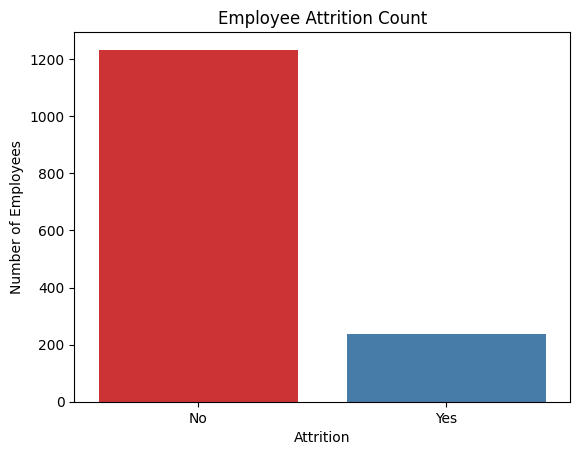

In [15]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# This will ignore all UserWarning messages

attrition= data['Attrition'].value_counts()
print(attrition)
print('\n--------------------------------')

sns.barplot(data=attrition,palette='Set1')
plt.title('Employee Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()


Gender  Attrition
Female  No           501
        Yes           87
Male    No           732
        Yes          150
dtype: int64

-----------------


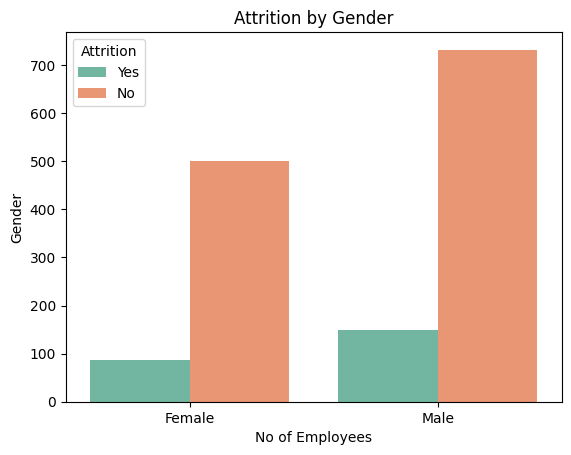

In [16]:
gen_atten = data.groupby(['Gender', 'Attrition']).size()
print(gen_atten)
print('\n-----------------')

sns.countplot(x='Gender', hue='Attrition', data=data, palette='Set2')
plt.title('Attrition by Gender')
plt.xlabel('No of Employees')
plt.ylabel('Gender')
plt.show()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

-----------------


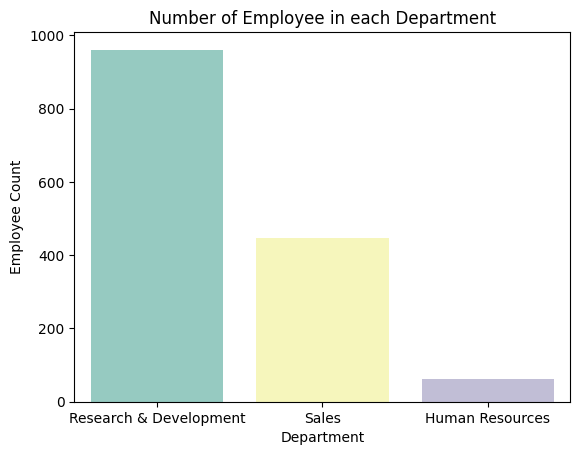

In [17]:
department= data['Department'].value_counts()
print(department)
print('\n-----------------')
sns.barplot(department,palette='Set3')
plt.title('Number of Employee in each Department')
plt.ylabel('Employee Count')
plt.xlabel('Department')
plt.show()

Education
Collage         572
Graduation      398
School          282
No Education    170
Masters          48
Name: count, dtype: int64

-----------------


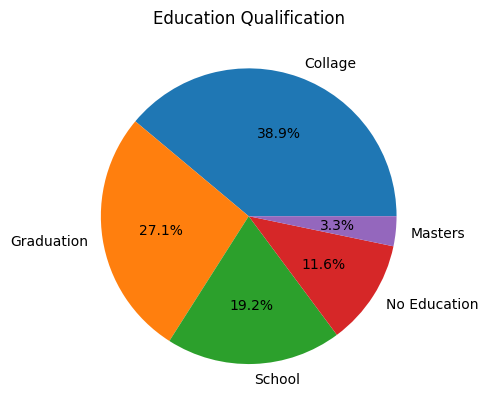

In [18]:
education=data['Education'].value_counts()
print(education)
print('\n-----------------')

plt.pie(education,labels=education.index,autopct='%.1f%%')
plt.title('Education Qualification')
plt.show()

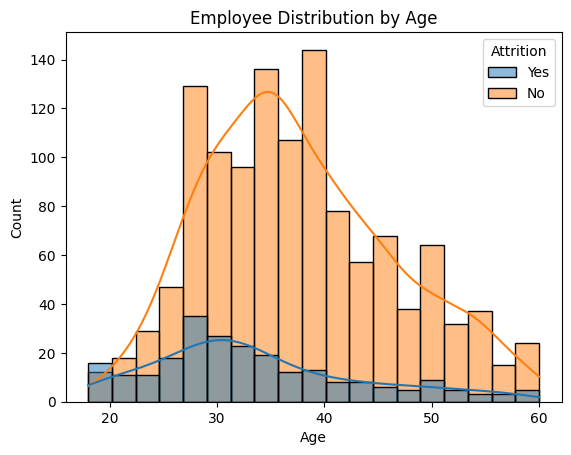

In [19]:
sns.histplot(x='Age',hue='Attrition',data=data,kde=True)
plt.title("Employee Distribution by Age")
plt.show()

PerformanceRating  Excellent  Outstanding
Attrition                                
No                      1044          189
Yes                      200           37

-----------------


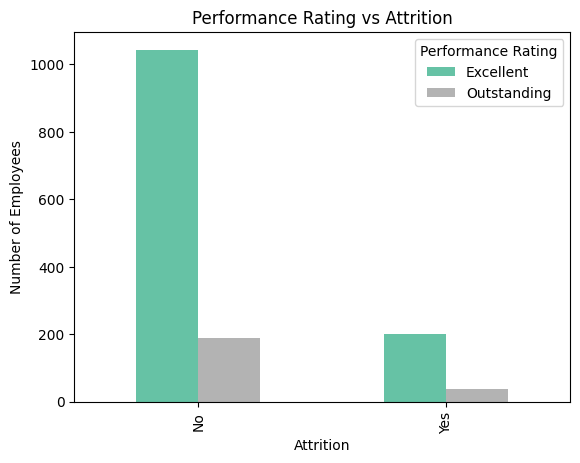

In [20]:
preformace_att= data.groupby(['Attrition','PerformanceRating']).size().unstack()
print(preformace_att)
print('\n-----------------')

preformace_att.plot(kind='bar', stacked=False, colormap='Set2')
plt.title('Performance Rating vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.legend(title='Performance Rating')
plt.show()

Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64

-----------------


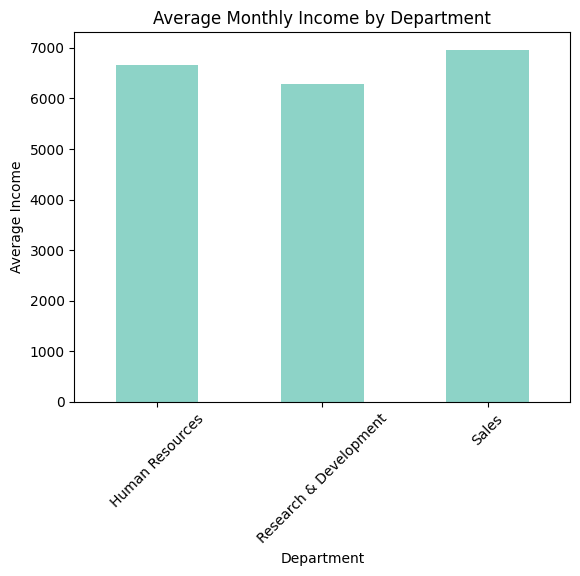

In [21]:
avg_salary=data.groupby('Department')['MonthlyIncome'].mean()
print(avg_salary)
#sns.barplot(x='Department', y='MonthlyIncome', data=data,estimator=np.mean,  palette='pastel')
print('\n-----------------')

avg_salary.plot(kind='bar', colormap='Set3')
plt.title('Average Monthly Income by Department')
plt.xticks(rotation=45)
plt.ylabel('Average Income')
plt.show()


MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

-------------------------------
MaritalStatus
Single      120
Married      84
Divorced     33
Name: count, dtype: int64

-------------------------------


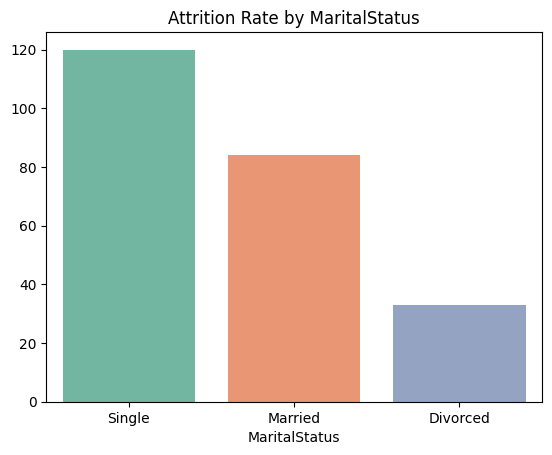

In [22]:
value_1 = data["MaritalStatus"].value_counts()
new_df = data[data["Attrition"]=="Yes"]
value_2 = new_df["MaritalStatus"].value_counts()
attrition_rate = np.floor((value_2/value_1)*100).values

print(value_1)
print('\n-------------------------------')
print(value_2)
print('\n-------------------------------')


sns.barplot(x=value_2.index, y=value_2.values,palette='Set2')
plt.title("Attrition Rate by MaritalStatus")
plt.show()

OverTime
No     1054
Yes     416
Name: Attrition, dtype: int64

-------------------------------


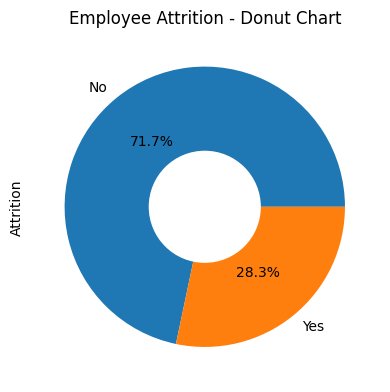

In [23]:
overtime=data.groupby('OverTime')['Attrition'].size()
print(overtime)
print('\n-------------------------------')

plt.figure(figsize=(4,5))
overtime.plot(kind='pie',autopct='%.1f%%')
centre_circle = plt.Circle((0, 0), 0.40, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Title
plt.title('Employee Attrition - Donut Chart')
plt.tight_layout()
plt.show()

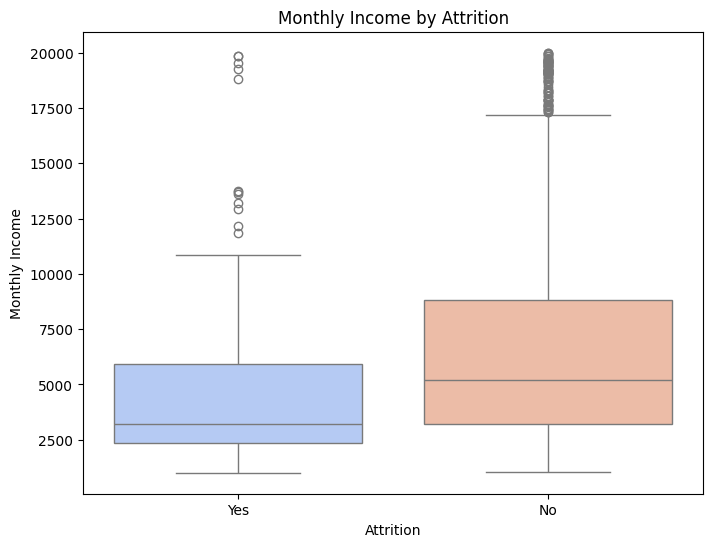

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data, palette='coolwarm')
plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()


In [25]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,School,Life Sciences,1,Medium,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,No Education,Life Sciences,2,High,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,School,Other,4,Very High,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Graduation,Life Sciences,5,Very High,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,No Education,Medical,7,Low,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [26]:
emp_sat= data['EnvironmentSatisfaction'].value_counts()
print(emp_sat)

EnvironmentSatisfaction
High         453
Very High    446
Medium       287
Low          284
Name: count, dtype: int64


<Axes: xlabel='EnvironmentSatisfaction', ylabel='Attrition'>

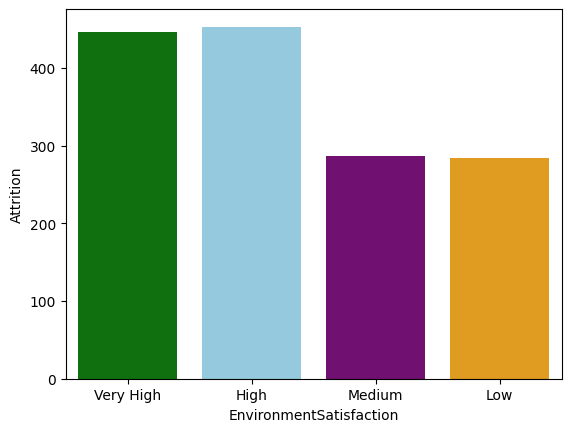

In [28]:
group= data.groupby('EnvironmentSatisfaction')['Attrition'].size()
orders=['Very High','High','Medium','Low']

#group.plot(kind='bar',order=orders,color=['green', 'skyblue', 'purple', 'orange'])
sns.barplot(group,order=orders,palette=['green', 'skyblue', 'purple', 'orange'])

<Figure size 500x500 with 0 Axes>

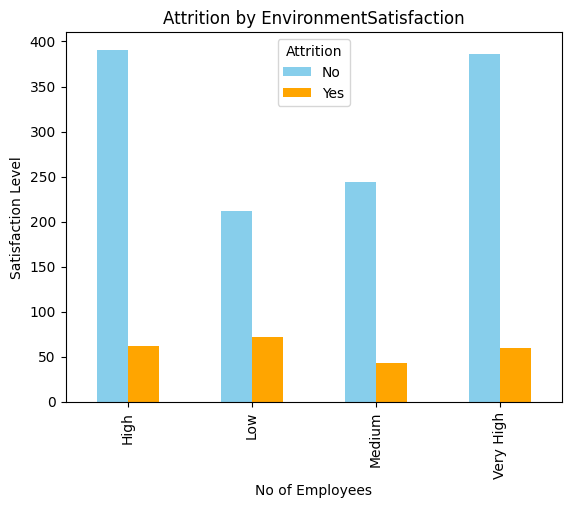

In [29]:
group= data.groupby(['EnvironmentSatisfaction','Attrition']).size().unstack()

plt.figure(figsize=(5,5))
group.plot(kind='bar',color=['skyblue','orange'])
plt.title('Attrition by EnvironmentSatisfaction' )
plt.xlabel('No of Employees')
plt.ylabel('Satisfaction Level')


plt.show()